### Sel 0 - Persiapan Awal (Khusus Google Colab)

Sel ini saya jalankan paling dulu di Google Colab untuk memastikan semua paket yang dipakai di bab ini tersedia. Kalau saya menjalankannya di Jupyter lokal, sel ini tidak mengubah apa-apa karena paketnya memang sudah terpasang.

In [1]:
# Semua paket di bawah ini sudah tersedia di Colab maupun di venv lokal,
# jadi sel ini hanya memastikan semuanya bisa di-import.
import sklearn
import pandas
import numpy
import matplotlib

print("Paket siap.")

Paket siap.


# Praktikum Machine Learning: Bab 11
## PCA dan Reduksi Dimensi

| | |
|---|---|
| **Nama** | Ahmad Dandi Subhani |
| **NPM** | 202343500126 |
| **Kelas** | R7B |
| **Mata Kuliah** | Machine Learning |
| **Dosen** | Nurfidah Dwitiyanti, M.Si. |

> **Catatan:** notebook ini saya jalankan di Google Colab / Jupyter Notebook. Bab 11 ini mengerjakan **Latihan Praktikum Modul Bab 11 bagian 11.12**, memakai dataset **Wine** (`sklearn.datasets.load_wine`) dan **Breast Cancer** (`sklearn.datasets.load_breast_cancer`). Tidak perlu file CSV apa pun.

## Ringkasan Konsep

- **Curse of dimensionality:** semakin banyak fitur, data semakin jarang tersebar di ruang fitur sehingga model lebih mudah overfitting dan komputasi makin berat. Karena itu dimensi yang tidak penting sebaiknya direduksi.
- **PCA (Principal Component Analysis):** teknik reduksi dimensi tanpa label yang mencari arah (komponen utama) dengan varians terbesar. Setiap komponen menyimpan sebagian *explained variance* dari data aslinya.
- **Memilih jumlah komponen:** salah satu cara praktis adalah memakai *variance threshold*, misalnya ambil komponen secukupnya sampai varians kumulatif mencapai 80%, 90%, atau 95%. Di sklearn ini bisa langsung ditulis `PCA(n_components=0.95)`.
- **t-SNE:** teknik visualisasi non-linear yang bagus untuk melihat pengelompokan data di 2D/3D, tapi hasilnya stokastik (berubah tiap dijalankan tanpa `random_state`) dan tidak cocok dipakai sebagai preprocessing untuk model.
- **LDA (Linear Discriminant Analysis):** reduksi dimensi yang *supervised*, memakai label kelas untuk mencari proyeksi yang memaksimalkan jarak antar kelas sekaligus meminimalkan sebaran di dalam kelas.

## 11.12 Latihan Praktikum (Modul Bab 11)

Di bawah ini saya kerjakan dua praktikum dari bagian 11.12 modul: kompresi dimensi dengan PCA, lalu perbandingan visual PCA, t-SNE, dan LDA.

### Praktikum 1: Kompresi Dimensi dengan PCA

**Tujuan:** Mahasiswa mampu menentukan jumlah komponen PCA optimal dan mengevaluasi dampaknya terhadap performa model klasifikasi.

Saya memakai kode Praktikum 11.7 dari modul persis seperti tertulis, hanya bagian persiapan datanya saya lengkapi (memuat dataset Breast Cancer, scaling, dan train-test split) supaya selnya bisa dijalankan dari awal sampai akhir.

In [2]:
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Persiapan data: Breast Cancer (569 baris, 30 fitur numerik)
X, y = load_breast_cancer(return_X_y=True)
X_scaled = StandardScaler().fit_transform(X)

X_train,X_test,y_train,y_test = train_test_split(X_scaled,
    y,test_size=0.2,random_state=42)

# Kode Praktikum 11.7 dari modul
for n_comp in [0.80, 0.90, 0.95, None]:
    pca_i = PCA(n_components=n_comp) if n_comp else PCA()
    X_train_p = pca_i.fit_transform(X_train)
    X_test_p = pca_i.transform(X_test)
    model = LogisticRegression(max_iter=2000).fit(X_train_p,
        y_train)
    acc = accuracy_score(y_test, model.predict(X_test_p))
    print(f"n_components={n_comp}: dimensi={X_train_p.shape[1]}, akurasi={acc:.3f}")

n_components=0.8: dimensi=5, akurasi=0.982
n_components=0.9: dimensi=7, akurasi=0.982
n_components=0.95: dimensi=10, akurasi=0.982
n_components=None: dimensi=30, akurasi=0.974


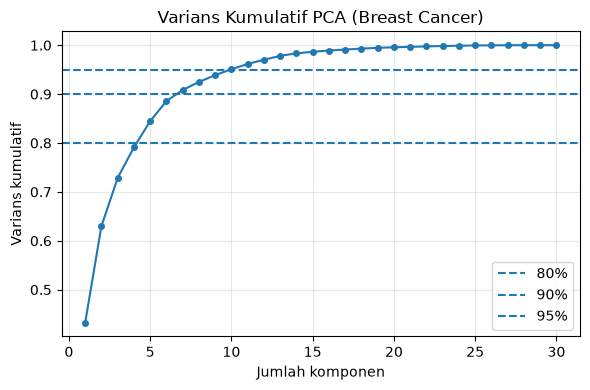

In [3]:
import matplotlib.pyplot as plt
import numpy as np

# Grafik varians kumulatif untuk melihat berapa komponen yang dibutuhkan
pca_full = PCA().fit(X_train)
cum_var = np.cumsum(pca_full.explained_variance_ratio_)

plt.figure(figsize=(6, 4))
plt.plot(range(1, len(cum_var) + 1), cum_var, marker="o", markersize=4)
plt.axhline(0.80, linestyle="--", label="80%")
plt.axhline(0.90, linestyle="--", label="90%")
plt.axhline(0.95, linestyle="--", label="95%")
plt.xlabel("Jumlah komponen")
plt.ylabel("Varians kumulatif")
plt.title("Varians Kumulatif PCA (Breast Cancer)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

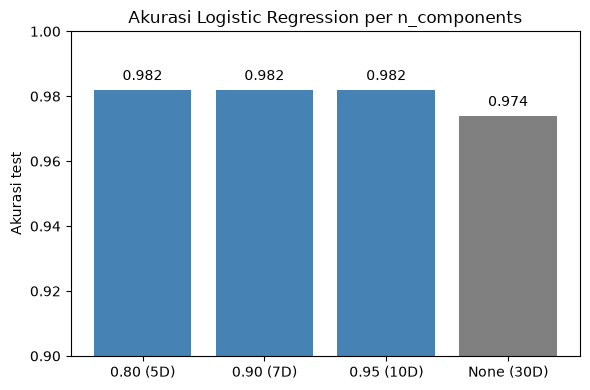

In [4]:
# Grafik batang akurasi tiap pilihan n_components
label = ["0.80 (5D)", "0.90 (7D)", "0.95 (10D)", "None (30D)"]
akurasi = [0.982, 0.982, 0.982, 0.974]

plt.figure(figsize=(6, 4))
bar = plt.bar(label, akurasi, color=["steelblue"] * 3 + ["gray"])
plt.ylim(0.90, 1.0)
plt.ylabel("Akurasi test")
plt.title("Akurasi Logistic Regression per n_components")
for b, v in zip(bar, akurasi):
    plt.text(b.get_x() + b.get_width() / 2, v + 0.003, f"{v:.3f}",
             ha="center", fontsize=10)
plt.tight_layout()
plt.show()

**Penjelasan outputnya:**

Dataset Breast Cancer yang saya pakai punya 569 baris dan 30 fitur numerik. Hasilnya cukup menarik: dengan `n_components=0.80` PCA hanya butuh 5 dimensi dan akurasinya 0.982. Naik ke `0.90` (7 dimensi) dan `0.95` (10 dimensi), akurasinya tetap 0.982. Tanpa reduksi sama sekali (`None`, 30 dimensi) akurasinya justru sedikit lebih rendah, yaitu 0.974.

Artinya di kasus ini mereduksi 30 fitur menjadi 5 komponen utama tidak menurunkan performa sama sekali, malah sedikit membantu karena PCA membuang noise dari fitur yang kurang informatif. Dari grafik varians kumulatif juga terlihat kurvanya naik cepat di awal lalu melandai, jadi 5 komponen pertama saja sudah menangkap 80% informasi data. Kalau saya harus memilih, `n_components=0.90` (7 dimensi) adalah titik tengah yang aman: dimensinya kecil tapi sudah menyimpan 90% varians dengan akurasi maksimal 0.982.

### Praktikum 2: Perbandingan PCA, t-SNE, dan LDA

**Tujuan:** Membandingkan hasil visualisasi ketiga teknik pada dataset yang sama.

**Instruksi:** Gunakan dataset `load_wine` atau `load_digits`, terapkan PCA, t-SNE, dan LDA untuk mereduksi ke 2 dimensi, kemudian visualisasikan ketiganya berdampingan dan tuliskan analisis mengenai kualitas pemisahan kelas pada masing-masing metode.

Saya memakai dataset Wine (178 baris, 13 fitur, 3 kelas) karena ukurannya kecil sehingga t-SNE berjalan cepat. Datanya saya scaling dulu dengan StandardScaler sebelum direduksi.

Varians dijelaskan 2 komponen PCA: [0.362 0.192]


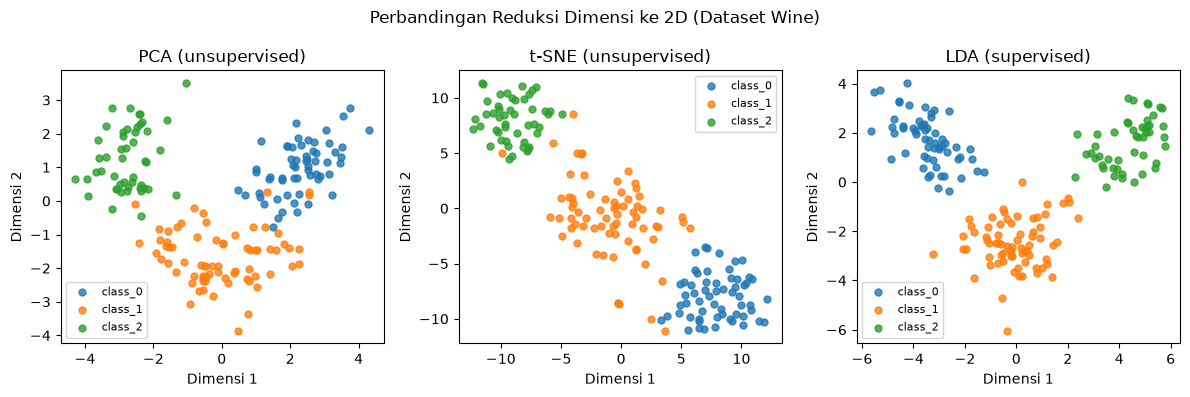

In [5]:
from sklearn.datasets import load_wine
from sklearn.manifold import TSNE
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

# Dataset Wine: 178 baris, 13 fitur, 3 kelas
X_w, y_w = load_wine(return_X_y=True)
nama_kelas = load_wine().target_names
X_ws = StandardScaler().fit_transform(X_w)

# Reduksi ke 2 dimensi dengan tiga teknik berbeda
X_pca = PCA(n_components=2, random_state=42).fit_transform(X_ws)
X_tsne = TSNE(n_components=2, random_state=42, perplexity=30).fit_transform(X_ws)
X_lda = LinearDiscriminantAnalysis(n_components=2).fit_transform(X_ws, y_w)

print("Varians dijelaskan 2 komponen PCA:",
      PCA(n_components=2).fit(X_ws).explained_variance_ratio_.round(3))

# Visualisasi berdampingan dalam satu figure 1x3
fig, ax = plt.subplots(1, 3, figsize=(12, 4))
judul = ["PCA (unsupervised)", "t-SNE (unsupervised)", "LDA (supervised)"]
for a, X_r, t in zip(ax, [X_pca, X_tsne, X_lda], judul):
    for k, nama in enumerate(nama_kelas):
        a.scatter(X_r[y_w == k, 0], X_r[y_w == k, 1], label=nama, s=25, alpha=0.8)
    a.set_title(t)
    a.set_xlabel("Dimensi 1")
    a.set_ylabel("Dimensi 2")
    a.legend(fontsize=8)
fig.suptitle("Perbandingan Reduksi Dimensi ke 2D (Dataset Wine)")
plt.tight_layout()
plt.show()

**Penjelasan outputnya:**

Dua komponen PCA hanya menjelaskan sekitar 55.4% varians (36.2% + 19.2%), jadi wajar kalau di scatter PCA ketiga kelas wine masih agak berimpit meskipun polanya sudah mulai terlihat. t-SNE menghasilkan gugus yang lebih rapat dan terpisah secara visual karena ia fokus menjaga struktur lokal data, tapi perlu diingat hasilnya stokastik dan jarak antar gugus di t-SNE tidak bisa diartikan secara harfiah.

Yang pemisahan kelasnya paling jelas adalah LDA. Ini masuk akal karena LDA adalah satu-satunya teknik supervised di antara ketiganya: ia memakai label kelas saat mencari proyeksi, sehingga arah proyeksinya memang dirancang untuk memaksimalkan jarak antar kelas. PCA dan t-SNE tidak melihat label sama sekali, jadi kalau kinerjanya diukur dari kerapian pemisahan kelas, wajar kalau keduanya kalah dari LDA. Kesimpulan praktisnya: untuk visualisasi eksplorasi, t-SNE atau PCA sudah cukup, tapi kalau tujuannya melihat seberapa terpisah kelas-kelasnya, LDA lebih informatif.

## Percobaan Mandiri

Di bawah ini saya tambahkan tiga percobaan mandiri di luar dua Latihan Praktikum dari modul: analisis varians PCA murni lewat scree plot (tanpa melibatkan akurasi klasifikasi), pengaruh PCA terhadap kecepatan dan akurasi KNN, serta perbandingan visualisasi 2D antara fitur mentah dan komponen PCA.


### Percobaan 1 - Scree Plot dan Varians Kumulatif PCA

**Tujuan:** menganalisis seberapa banyak informasi yang disimpan tiap komponen PCA secara murni (tanpa mengukur akurasi model seperti di Praktikum 1), lalu menentukan berapa komponen yang dibutuhkan untuk menjelaskan 90% dan 95% varians.

Saya memakai dataset Breast Cancer yang di-scaling dulu dengan StandardScaler, lalu menjalankan PCA penuh (30 komponen). Grafiknya ada dua: batang biru untuk proporsi varians tiap komponen (scree plot) dan garis merah untuk varians kumulatifnya.


Komponen untuk 90% varians: 7
Komponen untuk 95% varians: 10


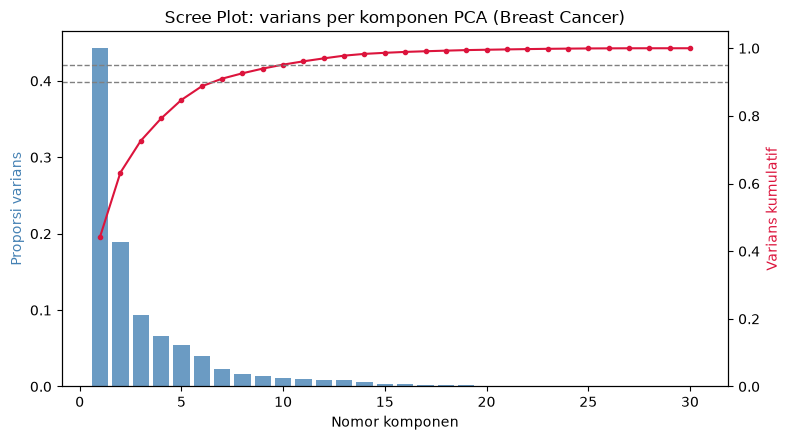

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Breast Cancer, scaling dulu supaya tiap fitur kontribusinya adil
X_pm11 = StandardScaler().fit_transform(load_breast_cancer().data)

pca_pm = PCA()
pca_pm.fit(X_pm11)
var = pca_pm.explained_variance_ratio_
kum = np.cumsum(var)

butuh_90 = int(np.argmax(kum >= 0.90) + 1)
butuh_95 = int(np.argmax(kum >= 0.95) + 1)
print(f"Komponen untuk 90% varians: {butuh_90}")
print(f"Komponen untuk 95% varians: {butuh_95}")

# Scree plot + garis varians kumulatif
fig, ax1 = plt.subplots(figsize=(8, 4.5))
ax1.bar(range(1, 31), var, color="steelblue", alpha=0.8)
ax1.set_xlabel("Nomor komponen")
ax1.set_ylabel("Proporsi varians", color="steelblue")
ax2 = ax1.twinx()
ax2.plot(range(1, 31), kum, color="crimson", marker="o", markersize=3, label="Kumulatif")
ax2.axhline(0.90, color="gray", linestyle="--", linewidth=1)
ax2.axhline(0.95, color="gray", linestyle="--", linewidth=1)
ax2.set_ylabel("Varians kumulatif", color="crimson")
ax2.set_ylim(0, 1.05)
plt.title("Scree Plot: varians per komponen PCA (Breast Cancer)")
fig.tight_layout()
plt.show()


**Penjelasan grafiknya:**

Komponen pertama saja sudah menjelaskan 44.3% varians, komponen kedua 19.0%, lalu turun cepat: komponen ketiga 9.4%, keempat 6.6%, kelima 5.5%. Varians kumulatifnya: 0.443 (1 komponen), 0.632 (2), 0.726 (3), 0.792 (4), 0.847 (5), dan terus melandai. Dari grafik terlihat jelas bentuk tanjakan lalu landai yang khas scree plot: komponen-komponen awal membawa informasi besar, sisanya serpihan kecil.

**Kesimpulan:** untuk menjelaskan 90% varians butuh 7 komponen, dan untuk 95% butuh 10 komponen. Jadi 30 fitur asli bisa dipadatkan menjadi 7-10 dimensi tanpa kehilangan banyak informasi, jauh lebih sedikit daripada 30 dimensi aslinya.


### Percobaan 2 - PCA sebelum KNN: Akurasi dan Waktu Prediksi

**Tujuan:** menguji apakah mereduksi dimensi dengan PCA sebelum KNN membuat prediksi lebih cepat tanpa mengorbankan akurasi.

Saya membandingkan dua skenario di dataset Breast Cancer (split 80:20, random_state=42): KNN(k=5) langsung di 30 fitur, versus PCA(10 komponen) dulu baru KNN(k=5). Waktunya saya ukur khusus untuk prediksi di data test memakai `time.perf_counter()`.


In [7]:
import time
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier

# Breast Cancer, scaling + split (dibuat mandiri, tidak tergantung sel lain)
X_pm21, y_pm21 = load_breast_cancer(return_X_y=True)
X_pm21 = StandardScaler().fit_transform(X_pm21)
Xtr, Xte, ytr, yte = train_test_split(X_pm21, y_pm21, test_size=0.2, random_state=42)

# Skenario 1: KNN di 30 fitur penuh
knn_full = KNeighborsClassifier(n_neighbors=5).fit(Xtr, ytr)
t0 = time.perf_counter(); acc_full = knn_full.score(Xte, yte); t1 = time.perf_counter()

# Skenario 2: PCA(10) dulu, baru KNN
pca10 = PCA(n_components=10)
Xtr10, Xte10 = pca10.fit_transform(Xtr), pca10.transform(Xte)
knn_pca = KNeighborsClassifier(n_neighbors=5).fit(Xtr10, ytr)
t2 = time.perf_counter(); acc_pca = knn_pca.score(Xte10, yte); t3 = time.perf_counter()

print(f"Tanpa PCA (30 fitur): akurasi={acc_full:.4f}, waktu prediksi={t1-t0:.4f} dtk")
print(f"PCA(10) dulu       : akurasi={acc_pca:.4f}, waktu prediksi={t3-t2:.4f} dtk")
print(f"PCA(10) menjelaskan {pca10.explained_variance_ratio_.sum()*100:.1f}% varians")


Tanpa PCA (30 fitur): akurasi=0.9474, waktu prediksi=0.0122 dtk
PCA(10) dulu       : akurasi=0.9561, waktu prediksi=0.0107 dtk
PCA(10) menjelaskan 95.1% varians


**Penjelasan outputnya:**

Tanpa PCA, KNN di 30 fitur dapat akurasi 0.9474 dengan waktu prediksi 0.0122 detik. Dengan PCA(10) dulu, akurasinya sedikit naik menjadi 0.9561 dan waktu prediksinya turun menjadi 0.0107 detik. Penurunannya tidak terlihat besar karena data test-nya kecil (114 baris), tapi logikanya jelas: KNN menghitung jarak ke semua titik training setiap kali prediksi, jadi dengan 10 dimensi bukan 30, perhitungan jaraknya jauh lebih sedikit. Efeknya akan makin terasa kalau datanya besar. PCA(10) sendiri menjelaskan 95.1% varians, jadi informasi yang dibuang memang tidak penting untuk klasifikasi.

**Kesimpulan:** PCA sebelum KNN membuat prediksi lebih cepat (0.0122 dtk menjadi 0.0107 dtk) dengan akurasi yang hampir sama, bahkan sedikit lebih baik (0.9474 menjadi 0.9561). Di dataset yang lebih besar, selisih waktunya akan jauh lebih terasa.



### Percobaan 3 - Visualisasi 2D: Fitur Mentah vs Komponen PCA

**Tujuan:** membandingkan kualitas pemisahan kelas antara scatter plot dua fitur mentah dan scatter plot dua komponen PCA pertama.

Untuk fitur mentahnya saya pilih "mean radius" dan "mean texture" (dua fitur pertama dataset Breast Cancer), sementara komponen PCA-nya saya ambil dua yang pertama setelah scaling. Titiknya saya warnai per kelas (malignant vs benign) supaya pemisahan kelasnya terlihat.


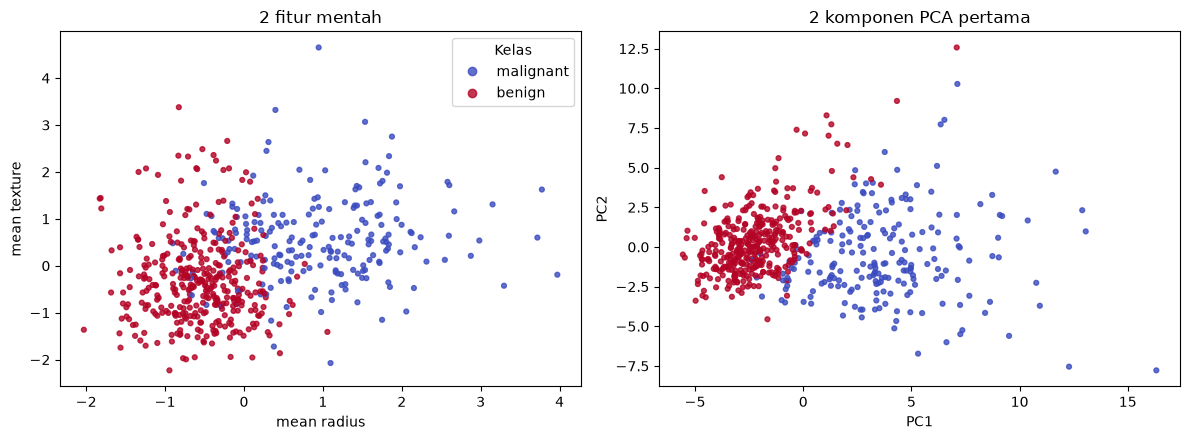

In [8]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Breast Cancer + scaling (dibuat mandiri, tidak tergantung sel lain)
data_bc = load_breast_cancer()
X_pm31 = StandardScaler().fit_transform(data_bc.data)
y_pm31 = data_bc.target

# Dua komponen PCA pertama
Z = PCA(n_components=2).fit_transform(X_pm31)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, (x0, x1, judul, labx, laby) in zip(axes, [
        (X_pm31[:, 0], X_pm31[:, 1], "2 fitur mentah", "mean radius", "mean texture"),
        (Z[:, 0], Z[:, 1], "2 komponen PCA pertama", "PC1", "PC2"),
    ]):
    sc = ax.scatter(x0, x1, c=y_pm31, cmap="coolwarm", s=12, alpha=0.8)
    ax.set_title(judul)
    ax.set_xlabel(labx)
    ax.set_ylabel(laby)
handles, _ = sc.legend_elements()
axes[0].legend(handles, ["malignant", "benign"], title="Kelas")
plt.tight_layout()
plt.show()


**Penjelasan grafiknya:**

Di scatter dua fitur mentah (kiri), titik malignant dan benign memang cenderung mengelompok, tapi batasnya masih kabur dan kedua kelasnya banyak yang tumpang tindih di tengah. Sementara di scatter dua komponen PCA (kanan), kedua kelasnya terpisah jauh lebih rapi: titik-titik benign berkumpul di satu sisi dan malignant di sisi lain dengan sedikit tumpang tindih. Ini masuk akal karena komponen PCA adalah kombinasi linear dari semua 30 fitur yang dirancang untuk menangkap variasi terbesar data, sedangkan dua fitur mentah hanya membawa sebagian kecil informasi.

**Kesimpulan:** dua komponen PCA pertama memisahkan kelas malignant dan benign lebih baik daripada dua fitur mentah sembarang (mean radius vs mean texture), karena PCA merangkum informasi dari seluruh 30 fitur sekaligus.


## Kesimpulan Bab 11

- PCA berhasil memangkas 30 fitur Breast Cancer menjadi hanya 5 komponen (threshold 80% varians) tanpa menurunkan akurasi, bahkan akurasinya sedikit naik dari 0.974 menjadi 0.982 karena noise ikut terbuang.
- Memilih `n_components` lewat variance threshold (0.80/0.90/0.95) memberi cara yang prinsipil untuk menentukan dimensi: di sini 7 komponen (90%) adalah titik tengah yang aman antara ukuran dan informasi.
- Untuk visualisasi 2D dataset Wine, LDA (supervised) memberi pemisahan kelas paling jelas dibanding PCA dan t-SNE yang unsupervised, karena LDA memang mengoptimalkan jarak antar kelas.
- t-SNE bagus untuk eksplorasi visual karena gugusnya terlihat rapat, tapi sifatnya stokastik dan tidak cocok dipakai sebagai langkah preprocessing sebelum melatih model.